In [1]:
import os
import gc
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from torch.amp import autocast, GradScaler
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
import albumentations as Albu
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import (
    accuracy_score, cohen_kappa_score, f1_score,
    recall_score, precision_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import sys
sys.path.append('../..')
from utils.dataset import PandasOverlapDataset


## Fixed Configuration

In [2]:
SEED         = 42
NUM_WORKERS  = 4
OUTPUT_CLASSES = 5      # ordinal thresholds for ISUP 0-5
WARMUP_EPOCHS  = 1
WARMUP_FACTOR  = 2
N_EPOCHS_FULL  = 50     # epochs for the final training run
N_EPOCHS_TRIAL = 8      # epochs per Optuna trial (short proxy)
PATIENCE       = 10     # early stopping patience (full run)
N_TRIALS       = 25     # Optuna trials
VAL_FOLD       = 3      # held-out fold
USE_AMP        = True   # mixed precision (fp16) — major VRAM saver

ROOT_DIR   = '../../..'
DATA_DIR   = '../../..'
IMAGES_DIR = os.path.join(DATA_DIR, 'bag_of_patches')

os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)

MODEL_PATH    = 'models/v2-overlap-0.pth'
LOG_PATH      = 'logs/v2-overlap-0.txt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # cuDNN benchmark speeds things up when input shapes are stable
    torch.backends.cudnn.benchmark = True

print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB')


Device: cuda
GPU: NVIDIA GeForce RTX 3060
Total VRAM: 12.49 GB


## VRAM Utility Helpers

In [3]:
def free_vram(*objs):
    """Aggressive cleanup: delete refs, run gc, empty CUDA cache."""
    for o in objs:
        try:
            del o
        except Exception:
            pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


def vram_report(tag=''):
    if not torch.cuda.is_available():
        return
    alloc = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(f'  [VRAM {tag}] allocated={alloc:.2f}GB reserved={reserved:.2f}GB peak={peak:.2f}GB')


## Loss Function

In [4]:
class OrdinalFocalLoss(nn.Module):

    def __init__(
        self,
        alpha: float = 0.25,
        gamma: float = 2.0,
        ordinal_weight: float = 0.2,
        reduction: str = 'mean'
    ):
        super().__init__()

        self.alpha = alpha
        self.gamma = gamma
        self.ordinal_weight = ordinal_weight
        self.reduction = reduction

    def forward(
        self,
        logits: torch.Tensor,
        targets: torch.Tensor
    ) -> torch.Tensor:

        # numerical stability under AMP
        logits = logits.float()
        targets = targets.float()

        probs = torch.sigmoid(logits)

        # BCE
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction='none'
        )

        # focal term
        p_t = probs * targets + (1 - probs) * (1 - targets)

        loss = self.alpha * ((1 - p_t) ** self.gamma) * bce

        # reduction
        if self.reduction == 'mean':
            focal_loss = loss.mean()
        elif self.reduction == 'sum':
            focal_loss = loss.sum()
        else:
            focal_loss = loss

        # ordinal penalty
        expected_class = probs.sum(dim=1)
        target_class = targets.sum(dim=1)

        max_class = logits.shape[1]

        ordinal_loss = (
            (expected_class - target_class) ** 2
        ).mean() / (max_class ** 2)

        # final loss
        total_loss = focal_loss + (
            self.ordinal_weight * ordinal_loss
        )

        return total_loss

def decode_ordinal_predictions(logits: torch.Tensor) -> torch.Tensor:
    return (torch.sigmoid(logits.float()) > 0.5).sum(dim=1)


## EfficientNetV2-S Wrapper

In [5]:
class EfficientNetV2Api(nn.Module):
    """
    EfficientNetV2-S wrapper with partial unfreezing.

    Args:
        model:            pretrained EfficientNetV2-S from torchvision
        output_dimensions: number of ordinal thresholds (5 for ISUP 0-5)
        dropout_rate:     dropout before the classification head
        unfreeze_blocks:  how many trailing feature blocks to unfreeze
                          (0 = head only; higher = more backbone unfrozen)
    """
    def __init__(
        self,
        model: nn.Module,
        output_dimensions: int,
        dropout_rate: float = 0.4,
        unfreeze_blocks: int = 2,
    ):
        super().__init__()
        self.model = model

        # Freeze entire backbone
        for param in self.model.parameters():
            param.requires_grad = False

        # Unfreeze trailing feature blocks
        if hasattr(self.model, 'features') and unfreeze_blocks > 0:
            for block in self.model.features[-unfreeze_blocks:]:
                for param in block.parameters():
                    param.requires_grad = True

        # Resolve head input features
        if isinstance(self.model.classifier, nn.Sequential):
            in_features = self.model.classifier[-1].in_features
        else:
            in_features = self.model.classifier.in_features

        self.model.classifier = nn.Identity()

        self.head = nn.Sequential(
            nn.LayerNorm(in_features),
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, output_dimensions),
        )

    def extract(self, x: torch.Tensor) -> torch.Tensor:
        x = self.model(x)
        if x.ndim == 4:
            x = x.mean(dim=[2, 3])
        return x

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.extract(x))


## Data Loading with Entropy Filtering

In [6]:

df_all = pd.read_csv(f'{ROOT_DIR}/repo/data/train_5fold.csv')

df_all.columns = df_all.columns.str.strip()
print(f'Total records: {len(df_all)}')

df_entropy = pd.read_csv(f'{ROOT_DIR}/repo/data/entropy.csv')
df_entropy_sorted = df_entropy.sort_values('difficulty_score', ascending=False)
n_remove = int(len(df_entropy_sorted) * 0.20)
noisy_ids = set(df_entropy_sorted.head(n_remove)['image_id'])
df_all = df_all[~df_all['image_id'].isin(noisy_ids)].reset_index(drop=True)
print(f'After entropy filter: {len(df_all)}')

def drop_missing(df, images_dir):
    exists = df['image_id'].apply(
        lambda x: os.path.isdir(os.path.join(images_dir, str(x)))
    )
    return df[exists].reset_index(drop=True)

train_idx = df_all['fold'] != VAL_FOLD
df_train = drop_missing(df_all[train_idx].reset_index(drop=True), IMAGES_DIR)
df_val   = drop_missing(df_all[~train_idx].reset_index(drop=True), IMAGES_DIR)
df_test  = drop_missing(pd.read_csv(f'{ROOT_DIR}/repo/data/test.csv'), IMAGES_DIR)

print(f'Train: {len(df_train)}  Val: {len(df_val)}  Test: {len(df_test)}')
print('Train class distribution:')
print(df_train['isup_grade'].value_counts().sort_index())


Total records: 9024
After entropy filter: 8844
Train: 7073  Val: 1767  Test: 1590
Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Augmentation

In [7]:
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
    Albu.RandomBrightnessContrast(p=0.3),
    Albu.HueSaturationValue(p=0.2),
])

val_transforms = None


## Training and Validation Helpers (AMP-enabled)

In [8]:
def make_loaders(batch_size: int):
    train_ds = PandasOverlapDataset(IMAGES_DIR, df_train, transforms=train_transforms, overlap=0)
    val_ds   = PandasOverlapDataset(IMAGES_DIR, df_val,   transforms=val_transforms, overlap=0)
    test_ds  = PandasOverlapDataset(IMAGES_DIR, df_test,  transforms=val_transforms, overlap=0)

    common = dict(
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        prefetch_factor=2 if NUM_WORKERS > 0 else None,
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=RandomSampler(train_ds), **common)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, **common)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, **common)
    return train_loader, val_loader, test_loader


def run_epoch_train(model, loader, optimizer, loss_fn, device, scaler, accum_steps=1):
    model.train()
    losses = []
    optimizer.zero_grad(set_to_none=True)

    for step, (imgs, targets, _) in enumerate(tqdm(loader, desc='Train', leave=False)):        
        imgs    = imgs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        with autocast(device_type='cuda', enabled=USE_AMP, dtype=torch.float16):
            logits = model(imgs)
            loss   = loss_fn(logits, targets) / accum_steps

        scaler.scale(loss).backward()

        if (step + 1) % accum_steps == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        losses.append(loss.item() * accum_steps)

    return float(np.mean(losses))


def run_epoch_val(model, loader, loss_fn, device):    
    model.eval()
    losses, preds, gts = [], [], []
    with torch.no_grad():
        for imgs, targets, _ in tqdm(loader, desc='Val', leave=False):
            imgs    = imgs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)
            with autocast(device_type='cuda', enabled=USE_AMP, dtype=torch.float16):
                logits = model(imgs)
                loss   = loss_fn(logits, targets)
            losses.append(loss.item())
            # immediately move to CPU to free VRAM
            preds.append(decode_ordinal_predictions(logits).cpu())
            gts.append(targets.sum(1).long().cpu())

    preds = torch.cat(preds).numpy()
    gts   = torch.cat(gts).numpy()
    kappa = cohen_kappa_score(gts, preds, weights='quadratic')
    acc   = accuracy_score(gts, preds)
    f1    = f1_score(gts, preds, average='macro', zero_division=0)
    return dict(val_loss=float(np.mean(losses)), val_kappa=kappa, val_acc=acc, val_f1=f1)


## Optuna Objective (with robust VRAM cleanup)

In [9]:
def build_model(dropout_rate: float, unfreeze_blocks: int) -> nn.Module:
    backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.DEFAULT)
    return EfficientNetV2Api(
        model=backbone,
        output_dimensions=OUTPUT_CLASSES,
        dropout_rate=dropout_rate,
        unfreeze_blocks=unfreeze_blocks,
    ).to(device)

## Full Training with Best Hyperparameters

In [10]:
# Final cleanup before the big run
free_vram()

best_params = {'lr': 0.00011053515666551402, 'dropout_rate': 0.4422658708964661, 'focal_gamma': 3.426017821026681, 'focal_alpha': 0.1673201260061349, 'unfreeze_blocks': 3, 'batch_size': 4, 'weight_decay': 1.037308225788563e-05}
print('Best hyperparameters:', best_params)

model   = build_model(best_params['dropout_rate'], best_params['unfreeze_blocks'])
loss_fn = OrdinalFocalLoss(alpha=best_params['focal_alpha'], gamma=best_params['focal_gamma'])
scaler  = GradScaler(enabled=USE_AMP)

train_loader, val_loader, test_loader = make_loaders(best_params['batch_size'])

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=best_params['lr'] / WARMUP_FACTOR,
    weight_decay=best_params['weight_decay'],
)
scheduler_cos = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=N_EPOCHS_FULL - WARMUP_EPOCHS
)
scheduler = GradualWarmupScheduler(
    optimizer, multiplier=WARMUP_FACTOR,
    total_epoch=WARMUP_EPOCHS, after_scheduler=scheduler_cos
)

print(f'\nStarting full training for up to {N_EPOCHS_FULL} epochs (patience={PATIENCE})\n')


Best hyperparameters: {'lr': 0.00011053515666551402, 'dropout_rate': 0.4422658708964661, 'focal_gamma': 3.426017821026681, 'focal_alpha': 0.1673201260061349, 'unfreeze_blocks': 3, 'batch_size': 4, 'weight_decay': 1.037308225788563e-05}

Starting full training for up to 50 epochs (patience=10)



In [11]:
history = dict(train_loss=[], val_loss=[], val_kappa=[], val_acc=[], val_f1=[])
best_kappa = 0.0
best_epoch = 0
no_improve = 0

if torch.cuda.is_available():
    torch.cuda.reset_peak_memory_stats()

for epoch in range(1, N_EPOCHS_FULL + 1):
    print(f'Epoch {epoch}/{N_EPOCHS_FULL}')

    train_loss = run_epoch_train(model, train_loader, optimizer, loss_fn, device, scaler)
    metrics    = run_epoch_val(model, val_loader, loss_fn, device)
    scheduler.step()
    lr_now = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    for k in ('val_loss', 'val_kappa', 'val_acc', 'val_f1'):
        history[k].append(metrics[k])

    print(f'  train_loss={train_loss:.5f}  val_loss={metrics["val_loss"]:.5f}  '
          f'kappa={metrics["val_kappa"]:.4f}  acc={metrics["val_acc"]*100:.2f}%  lr={lr_now:.7f}')
    vram_report(f'epoch {epoch}')

    with open(LOG_PATH, 'a') as f:
        f.write(
            f'epoch: {epoch} | lr: {lr_now:.7f} | '
            f'train_loss: {train_loss:.5f} | val_loss: {metrics["val_loss"]:.5f} | '
            f'val_kappa: {metrics["val_kappa"]:.4f} | val_acc: {metrics["val_acc"]:.4f}\n'
        )

    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        no_improve = 0
        torch.save(model.state_dict(), MODEL_PATH)
        print(f'  ** Best model saved (QWK={best_kappa:.4f})')
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}. Best: epoch {best_epoch} QWK={best_kappa:.4f}')
            break

print(f'\nTraining finished. Best QWK: {best_kappa:.4f} at epoch {best_epoch}')


Epoch 1/50


  train_loss=0.02651  val_loss=0.01516  kappa=0.7945  acc=58.12%  lr=0.0001105
  [VRAM epoch 1] allocated=0.25GB reserved=0.48GB peak=8.41GB
  ** Best model saved (QWK=0.7945)
Epoch 2/50


/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)


  train_loss=0.02144  val_loss=0.01541  kappa=0.8065  acc=56.48%  lr=0.0001106
  [VRAM epoch 2] allocated=0.25GB reserved=9.07GB peak=8.41GB
  ** Best model saved (QWK=0.8065)
Epoch 3/50


  train_loss=0.01787  val_loss=0.01326  kappa=0.8244  acc=58.06%  lr=0.0001105
  [VRAM epoch 3] allocated=0.25GB reserved=9.07GB peak=8.41GB
  ** Best model saved (QWK=0.8244)
Epoch 4/50


...

  train_loss=0.00411  val_loss=0.01711  kappa=0.8724  acc=69.44%  lr=0.0000536
  [VRAM epoch 27] allocated=0.25GB reserved=9.07GB peak=8.41GB
Epoch 28/50


  train_loss=0.00367  val_loss=0.01845  kappa=0.8686  acc=66.84%  lr=0.0000500
  [VRAM epoch 28] allocated=0.25GB reserved=9.07GB peak=8.41GB
Epoch 29/50


  train_loss=0.00344  val_loss=0.01768  kappa=0.8643  acc=68.48%  lr=0.0000465
  [VRAM epoch 29] allocated=0.25GB reserved=9.07GB peak=8.41GB
Epoch 30/50


  train_loss=0.00339  val_loss=0.02183  kappa=0.8663  acc=68.14%  lr=0.0000430
  [VRAM epoch 30] allocated=0.25GB reserved=9.07GB peak=8.41GB
Epoch 31/50


  train_loss=0.00297  val_loss=0.01886  kappa=0.8653  acc=67.29%  lr=0.0000396
  [VRAM epoch 31] allocated=0.25GB reserved=9.07GB peak=8.41GB

Early stopping at epoch 31. Best: epoch 21 QWK=0.8743

Training finished. Best QWK: 0.8743 at epoch 21


## Training Curves

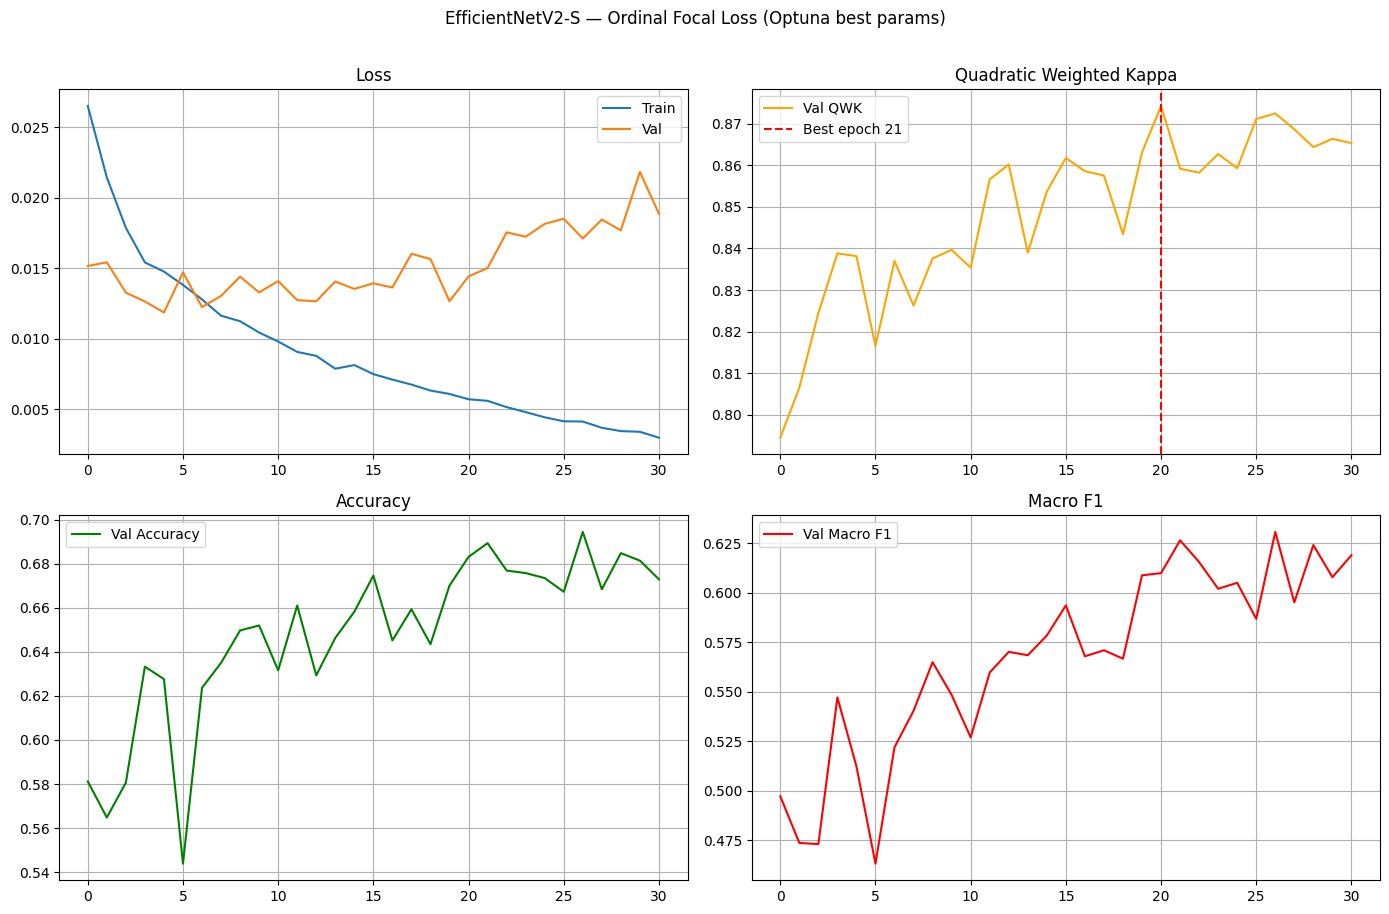

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(history['train_loss'], label='Train')
axes[0, 0].plot(history['val_loss'],   label='Val')
axes[0, 0].set_title('Loss')
axes[0, 0].legend(); axes[0, 0].grid(True)

axes[0, 1].plot(history['val_kappa'], color='orange', label='Val QWK')
axes[0, 1].axvline(best_epoch - 1, color='red', linestyle='--', label=f'Best epoch {best_epoch}')
axes[0, 1].set_title('Quadratic Weighted Kappa')
axes[0, 1].legend(); axes[0, 1].grid(True)

axes[1, 0].plot(history['val_acc'], color='green', label='Val Accuracy')
axes[1, 0].set_title('Accuracy')
axes[1, 0].legend(); axes[1, 0].grid(True)

axes[1, 1].plot(history['val_f1'], color='red', label='Val Macro F1')
axes[1, 1].set_title('Macro F1')
axes[1, 1].legend(); axes[1, 1].grid(True)

plt.suptitle('EfficientNetV2-S — Ordinal Focal Loss (Optuna best params)', y=1.01)
plt.tight_layout()
plt.savefig('logs/v2-optuna-ordinal-focal-training.png', dpi=300, bbox_inches='tight')
plt.show()


## Test-Set Evaluation with Bootstrap CI

In [13]:
model.load_state_dict(torch.load(MODEL_PATH, weights_only=True))
model.eval()

test_preds, test_gts = [], []
with torch.no_grad():
    for imgs, targets, _ in tqdm(test_loader, desc='Test'):
        imgs = imgs.to(device, non_blocking=True)
        with autocast(device_type='cuda', enabled=USE_AMP, dtype=torch.float16):
            logits = model(imgs)
        test_preds.append(decode_ordinal_predictions(logits).cpu())
        test_gts.append(targets.sum(1).long())

test_preds = torch.cat(test_preds).numpy()
test_gts   = torch.cat(test_gts).numpy()

# ── Point estimates ───────────────────────────────────────────────────
pt_acc   = accuracy_score(test_gts, test_preds)
pt_kappa = cohen_kappa_score(test_gts, test_preds, weights='quadratic')
pt_f1    = f1_score(test_gts, test_preds, average='macro', zero_division=0)

# ── Bootstrap (1 000 resamples, 95% CI) ──────────────────────────────
N_BOOT = 1000
rng    = np.random.default_rng(SEED)
n      = len(test_gts)
boot   = dict(acc=np.empty(N_BOOT), kappa=np.empty(N_BOOT), f1=np.empty(N_BOOT))

for i in tqdm(range(N_BOOT), desc='Bootstrap'):
    idx            = rng.integers(0, n, size=n)
    boot['acc'][i]   = accuracy_score(test_gts[idx], test_preds[idx])
    boot['kappa'][i] = cohen_kappa_score(test_gts[idx], test_preds[idx], weights='quadratic')
    boot['f1'][i]    = f1_score(test_gts[idx], test_preds[idx], average='macro', zero_division=0)

def ci(arr):
    return arr.std(ddof=1), np.percentile(arr, 2.5), np.percentile(arr, 97.5)

acc_s,   acc_lo,   acc_hi   = ci(boot['acc'])
kap_s,   kap_lo,   kap_hi   = ci(boot['kappa'])
f1_s,    f1_lo,    f1_hi    = ci(boot['f1'])

print('\n' + '='*70)
print('TEST SET RESULTS — EfficientNetV2-S + Ordinal Focal Loss (Optuna)')
print('='*70)
print(f'Accuracy : {pt_acc*100:.2f}% ± {acc_s*100:.2f}%  '
      f'[95% CI: {acc_lo*100:.2f}%–{acc_hi*100:.2f}%]')
print(f'QW Kappa : {pt_kappa:.4f} ± {kap_s:.4f}  '
      f'[95% CI: {kap_lo:.4f}–{kap_hi:.4f}]')
print(f'Macro F1 : {pt_f1:.4f} ± {f1_s:.4f}  '
      f'[95% CI: {f1_lo:.4f}–{f1_hi:.4f}]')
print('='*70)
print()
print(classification_report(test_gts, test_preds,
      target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))


Bootstrap: 100%|██████████| 1000/1000 [00:02<00:00, 487.70it/s]


TEST SET RESULTS — EfficientNetV2-S + Ordinal Focal Loss (Optuna)
Accuracy : 65.72% ± 1.22%  [95% CI: 63.27%–68.05%]
QW Kappa : 0.8580 ± 0.0113  [95% CI: 0.8326–0.8781]
Macro F1 : 0.5763 ± 0.0129  [95% CI: 0.5499–0.5996]

              precision    recall  f1-score   support

      ISUP 0     0.8054    0.9539    0.8734       434
      ISUP 1     0.7387    0.7350    0.7368       400
      ISUP 2     0.5145    0.3550    0.4201       200
      ISUP 3     0.4397    0.3351    0.3804       185
      ISUP 4     0.4261    0.4011    0.4132       187
      ISUP 5     0.5785    0.7011    0.6339       184

    accuracy                         0.6572      1590
   macro avg     0.5838    0.5802    0.5763      1590
weighted avg     0.6386    0.6572    0.6428      1590



## Confusion Matrices

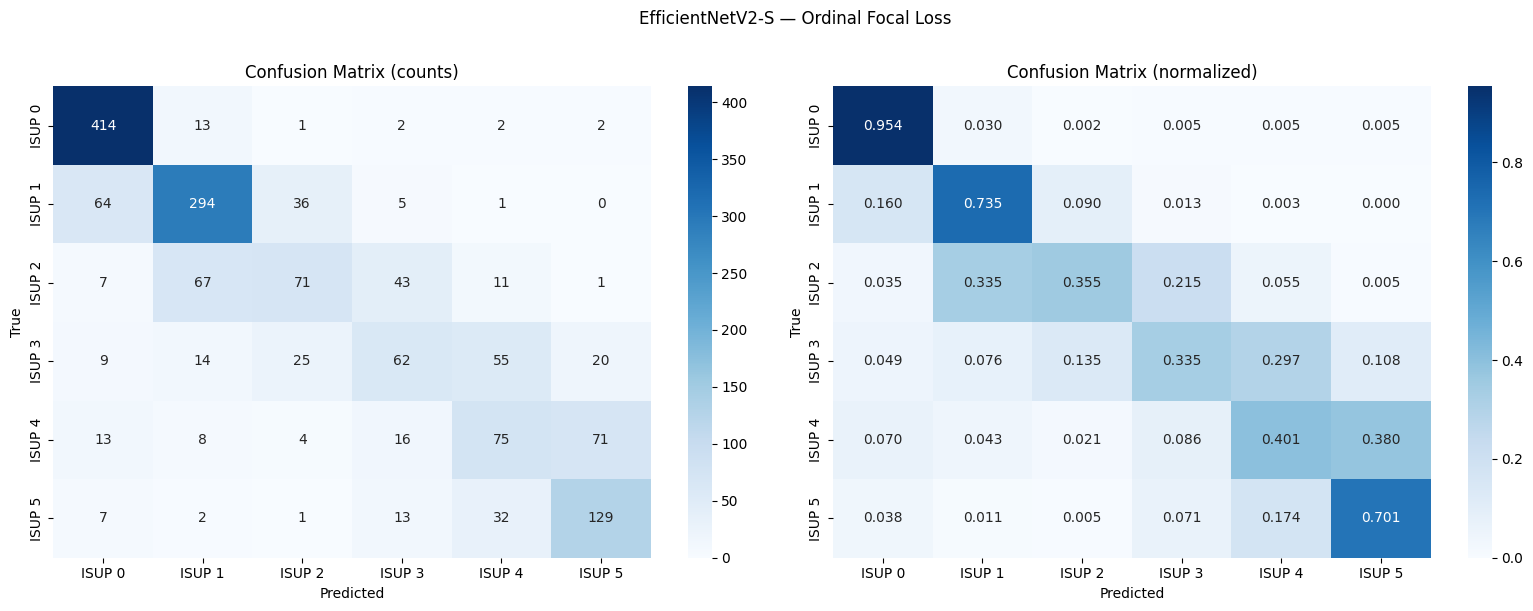

In [14]:
cm      = confusion_matrix(test_gts, test_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
labels  = [f'ISUP {i}' for i in range(6)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')

sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalized)')
axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')

plt.suptitle('EfficientNetV2-S — Ordinal Focal Loss', y=1.01)
plt.tight_layout()
plt.savefig('logs/v2-optuna-ordinal-focal-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()


## Save Results

In [15]:
results_path = 'logs/v2-optuna-ordinal-focal-results.txt'
with open(results_path, 'w') as f:
    f.write('EfficientNetV2-S + Ordinal Focal Loss (Optuna HPO)\n')
    f.write('='*70 + '\n\n')
    f.write('Best Optuna hyperparameters:\n')
    for k, v in best_params.items():
        f.write(f'  {k}: {v}\n')
    f.write(f'Bootstrap resamples: {N_BOOT}\n\n')
    f.write(f'Accuracy : {pt_acc*100:.2f}% ± {acc_s*100:.2f}%  '
            f'[95% CI: {acc_lo*100:.2f}%–{acc_hi*100:.2f}%]\n')
    f.write(f'QW Kappa : {pt_kappa:.4f} ± {kap_s:.4f}  '
            f'[95% CI: {kap_lo:.4f}–{kap_hi:.4f}]\n')
    f.write(f'Macro F1 : {pt_f1:.4f} ± {f1_s:.4f}  '
            f'[95% CI: {f1_lo:.4f}–{f1_hi:.4f}]\n\n')
    f.write('Classification Report:\n')
    f.write(classification_report(test_gts, test_preds,
            target_names=labels, digits=4, zero_division=0))
    f.write('\nConfusion Matrix:\n')
    f.write(str(cm) + '\n')

print(f'Results saved to {results_path}')


Results saved to logs/v2-optuna-ordinal-focal-results.txt
